**Data Preprocessing**

1. Re-Orientation
2. Skull Stripping
3. Bias Field Correction
4. Intensity Normalisation
5. Resampling
6. Cropping / Padding
7. Resizing
8. Data Augmentation: Degree & Translation

**1. Re-Orientation**

In [1]:
import ants
import antspynet

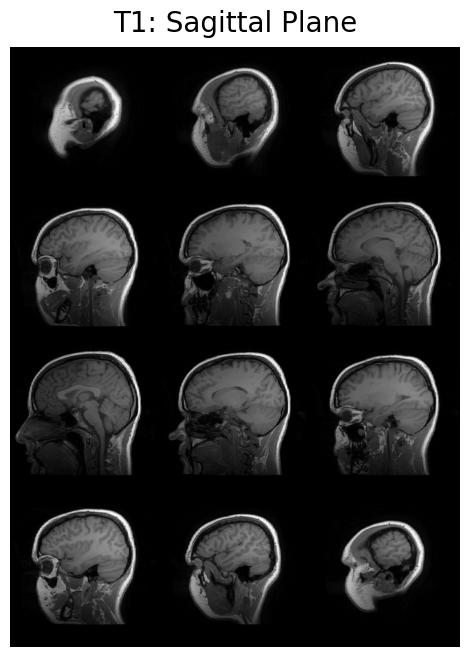

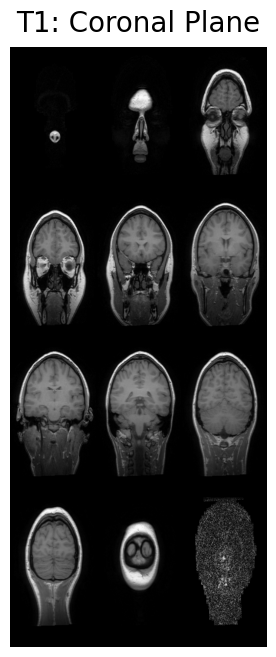

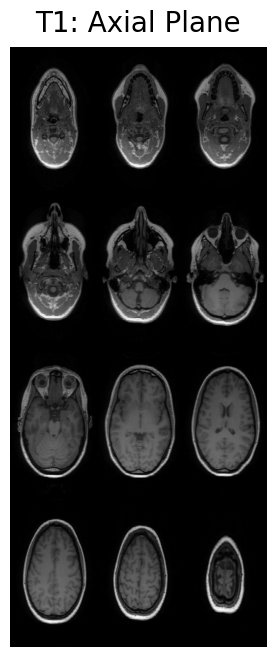

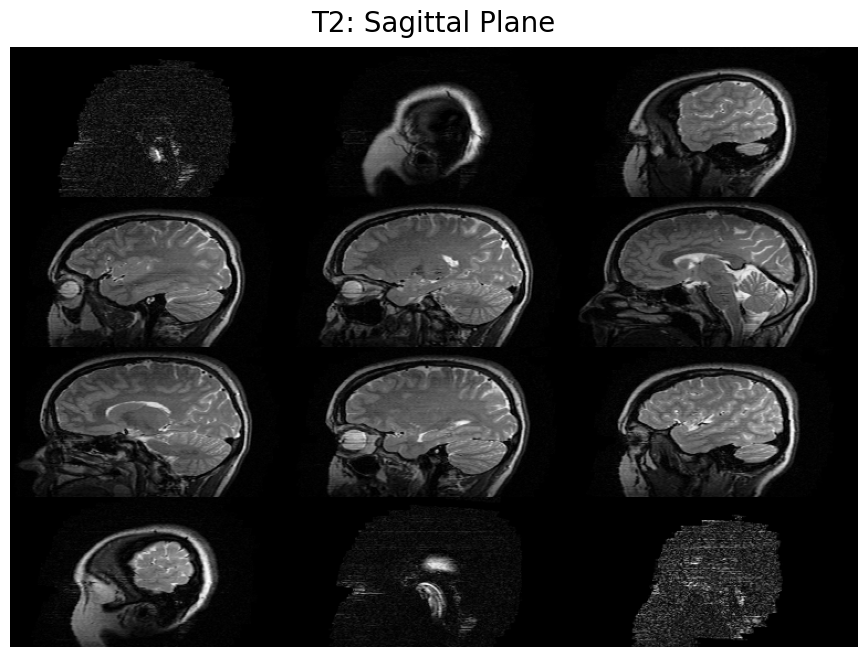

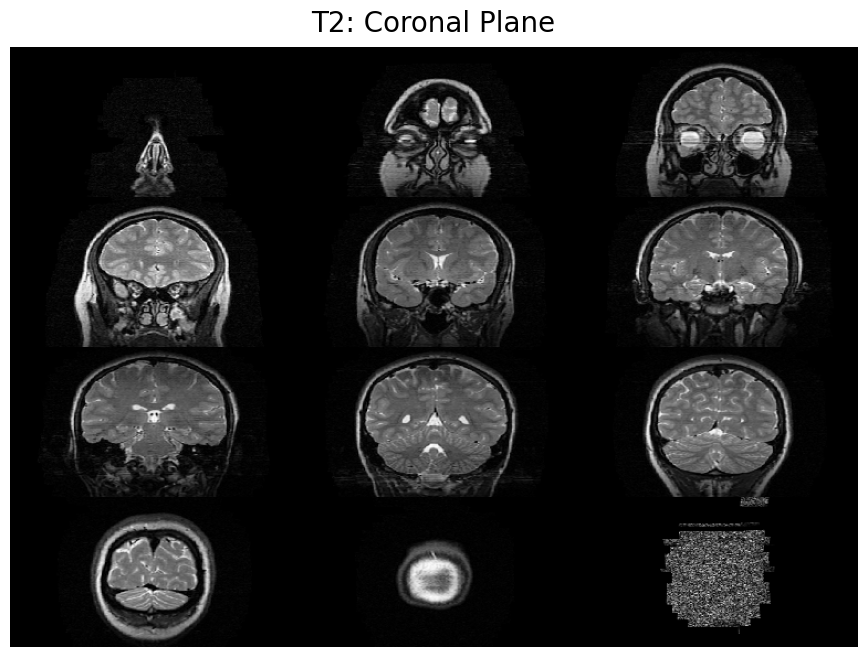

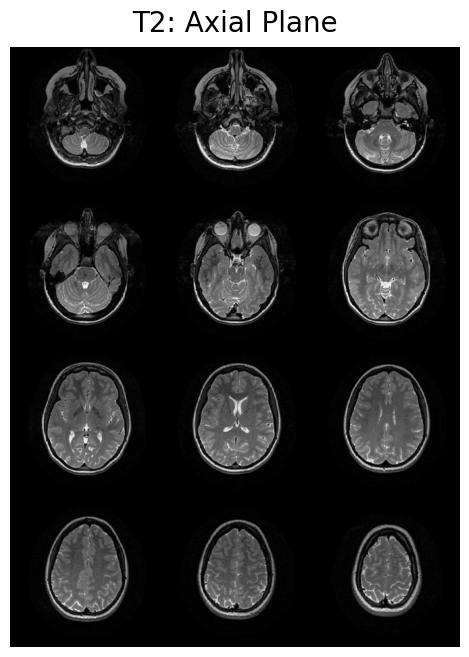

In [2]:
# Load the image
t1 = ants.image_read(r"C:\Users\hp\Downloads\IXI-T1\IXI425-IOP-0988-T1.nii.gz")
t2 = ants.image_read(r"C:\Users\hp\Downloads\IXI-T2\IXI425-IOP-0988-T2.nii.gz")

# Reorient the image (RAS orientation)
reoriented_t1 = ants.reorient_image2(t1, orientation='RAS')
reoriented_t2 = ants.reorient_image2(t2, orientation='RAS')

# Plot the reoriented image 
ants.plot(reoriented_t1, axis=0, title='T1: Sagittal Plane')
ants.plot(reoriented_t1, axis=1, title='T1: Coronal Plane')
ants.plot(reoriented_t1, axis=2, title='T1: Axial Plane')

ants.plot(reoriented_t2, axis=0, title='T2: Sagittal Plane')
ants.plot(reoriented_t2, axis=1, title='T2: Coronal Plane')
ants.plot(reoriented_t2, axis=2, title='T2: Axial Plane')

**2. Skull Stripping**

Brain extraction:  retrieving model weights.
Brain extraction:  retrieving template.
Brain extraction:  normalizing image to the template.
Brain extraction:  prediction and decoding.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Brain extraction:  renormalize probability mask to native space.
Brain extraction:  retrieving model weights.
Brain extraction:  retrieving template.
Brain extraction:  normalizing image to the template.
Brain extraction:  prediction and decoding.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Brain extraction:  renormalize probability mask to native space.


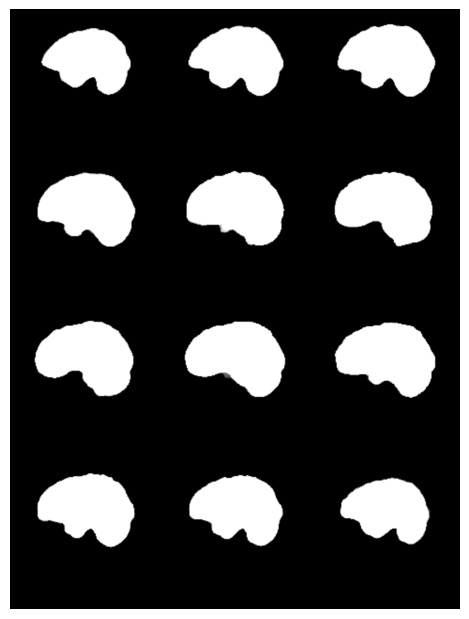

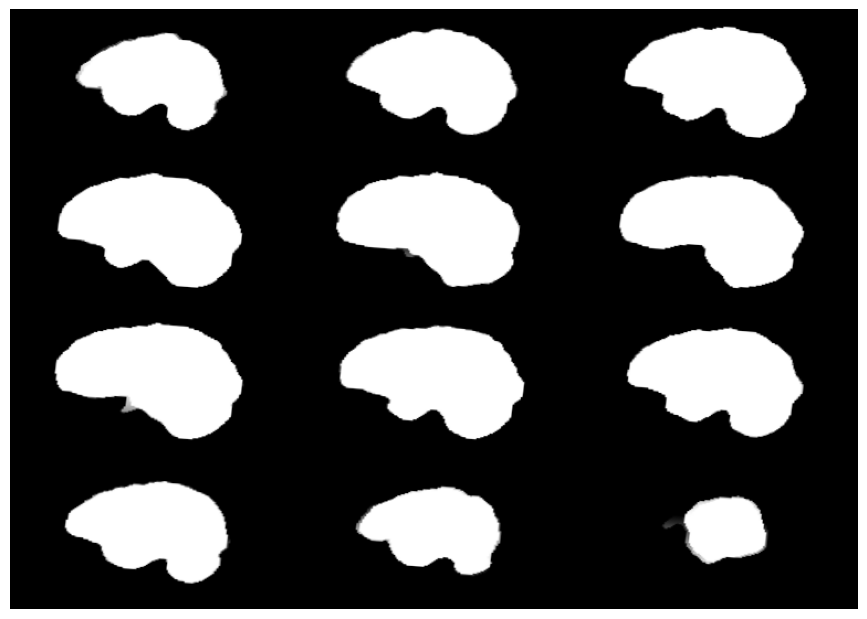

In [3]:
brain_mask_t1 = antspynet.brain_extraction(reoriented_t1, modality="t1", verbose=True)
brain_mask_t2 = antspynet.brain_extraction(reoriented_t2, modality="t2", verbose=True)

ants.plot(brain_mask_t1)
ants.plot(brain_mask_t2)

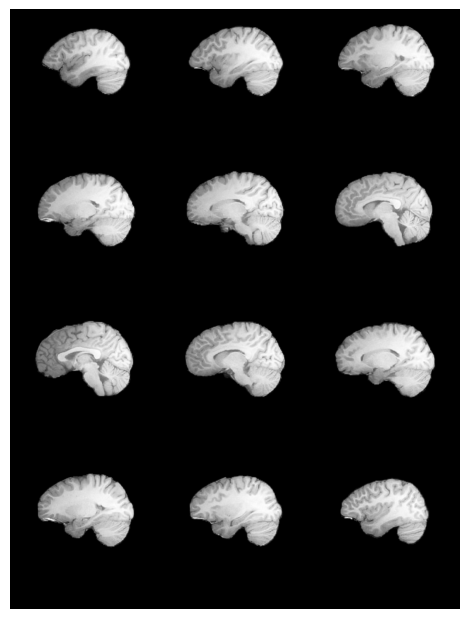

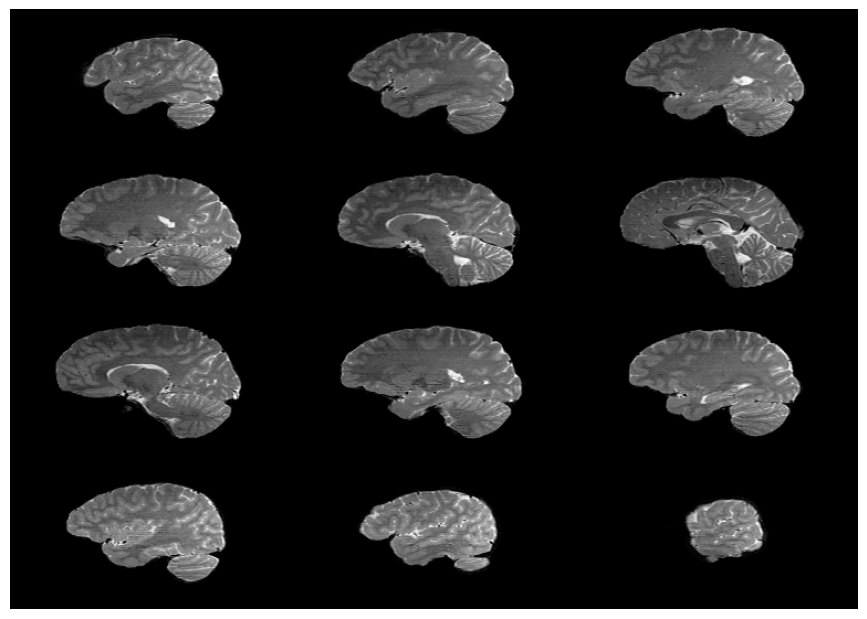

In [4]:
stripped_t1 = reoriented_t1 * brain_mask_t1
stripped_t2 = reoriented_t2 * brain_mask_t2['segmentation_image']

ants.plot(stripped_t1)
ants.plot(stripped_t2)

**3. Bias Field Correction**

In [58]:
import SimpleITK as sitk
import matplotlib.pyplot as plt

In [45]:
sitk_t1 = sitk.GetImageFromArray(stripped_t1.numpy())
sitk_t2 = sitk.GetImageFromArray(stripped_t2.numpy())

corrected_t1 = sitk.N4BiasFieldCorrection(sitk_t1)
corrected_t2 = sitk.N4BiasFieldCorrection(sitk_t2)

In [ ]:
# Convert SimpleITK image to numpy array for visualization
array_b4_corrected_t1 = sitk.GetArrayFromImage(sitk_t1)
array_b4_corrected_t2 = sitk.GetArrayFromImage(sitk_t2)

array_corrected_t1 = sitk.GetArrayFromImage(corrected_t1)
array_corrected_t2 = sitk.GetArrayFromImage(corrected_t2)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Plot before correction 
axes[0, 0].imshow(array_b4_corrected_t1[array_b4_corrected_t1.shape[0] // 2, :, :], cmap='gray')
axes[0, 0].set_title("Before Bias Field Correction: T1 Sagittal Plane")
axes[0, 0].axis('off')

axes[1, 0].imshow(array_b4_corrected_t2[array_b4_corrected_t2.shape[0] // 2, :, :], cmap='gray')
axes[1, 0].set_title("Before Bias Field Correction: T2 Sagittal Plane")
axes[1, 0].axis('off')

# Plot after correction 
axes[0, 1].imshow(array_corrected_t1[array_corrected_t1.shape[0] // 2, :, :], cmap='gray')
axes[0, 1].set_title("After Bias Field Correction: T1 Sagittal Plane")
axes[0, 1].axis('off')

axes[1, 1].imshow(array_corrected_t2[array_corrected_t2.shape[0] // 2, :, :], cmap='gray')
axes[1, 1].set_title("After Bias Field Correction: T2 Sagittal Plane")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

**4. Intensity Normalisation**

In [5]:
import torchio as tio

<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
c:\Users\hp\OneDrive\Documents\fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
import torch
torchio_t1_from_ant = tio.ScalarImage(tensor=torch.from_numpy(stripped_t1.numpy()).unsqueeze(0))
torchio_t2_from_ant = tio.ScalarImage(tensor=torch.from_numpy(stripped_t2.numpy()).unsqueeze(0))

torchio_t1_mask = tio.ScalarImage(tensor=torch.from_numpy(brain_mask_t1.numpy()).unsqueeze(0))
torchio_t2_mask = tio.ScalarImage(tensor=torch.from_numpy(brain_mask_t2.numpy()).unsqueeze(0))

Before Normalisation T1 : Mean -tensor(301.6281) Max -tensor(5094.)
After Normalisation T1 : Mean -tensor(0.0741) Max -tensor(1.)

Before Normalisation T2 : Mean -tensor(117.6968) Max -tensor(3726.)
After Normalisation T2 : Mean -tensor(0.0691) Max -tensor(1.)


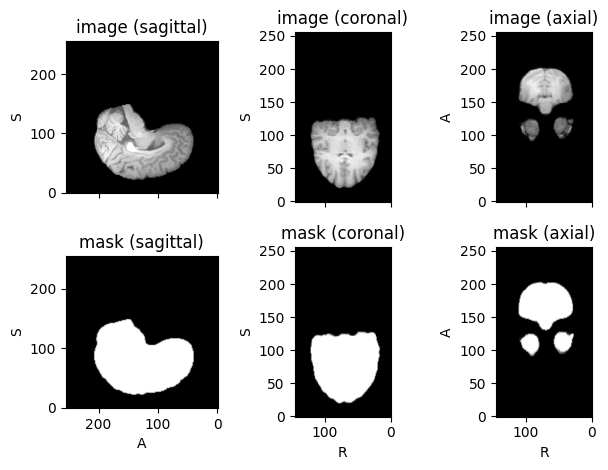

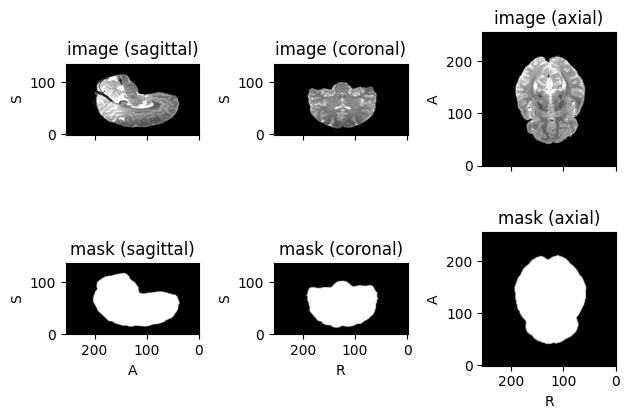

In [17]:
# Convert the SimpleITK image to Torchio ScalarImage
# torchio_t1 = tio.ScalarImage.from_sitk(corrected_t1)
# torchio_t2 = tio.ScalarImage.from_sitk(corrected_t2)

# Normalise the images
torchio_subject_t1 = tio.Subject(image=torchio_t1_from_ant, mask=torchio_t1_mask)
torchio_subject_t2 = tio.Subject(image=torchio_t2_from_ant, mask=torchio_t2_mask)
normalised_t1 = tio.RescaleIntensity(percentiles=(0,99), masking_method=lambda x:x>0)(torchio_subject_t1)
normalised_t2 = tio.RescaleIntensity(percentiles=(0,99), masking_method=lambda x:x>0)(torchio_subject_t2)

print("Before Normalisation T1 : Mean -" + str(torchio_t1_from_ant.data.mean()) + " Max -" + str(torchio_t1_from_ant.data.max()))
print("After Normalisation T1 : Mean -" + str(normalised_t1.image.data.mean()) + " Max -" + str(normalised_t1.image.data.max()) + "\n")
print("Before Normalisation T2 : Mean -" + str(torchio_t2_from_ant.data.mean()) + " Max -" + str(torchio_t2_from_ant.data.max()))
print("After Normalisation T2 : Mean -" + str(normalised_t2.image.data.mean()) + " Max -" + str(normalised_t2.image.data.max()))

# Plot the normalised images
normalised_t1.plot()
normalised_t2.plot()

**5. Resampling**

Original voxel size T1:  (1.0, 1.0, 1.0)
Resampled voxel size T1:  (1.0, 1.0, 1.0)

 Original voxel size T2:  (1.0, 1.0, 1.0)
Resampled voxel size T2:  (1.0, 1.0, 1.0)


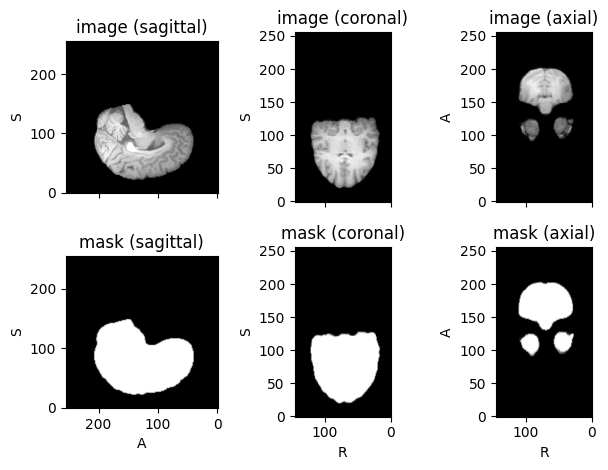

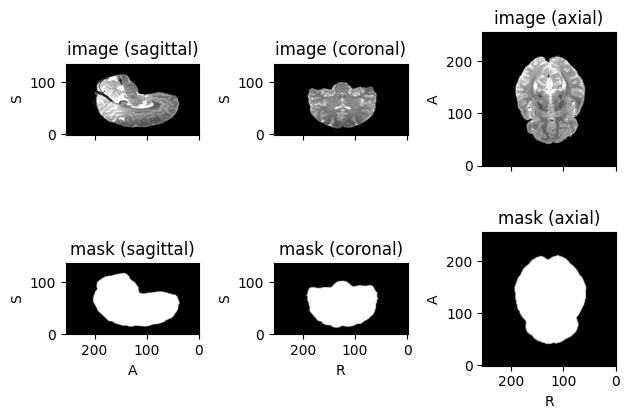

In [18]:
resampled_t1 = tio.Resample(1)(normalised_t1)
resampled_t2 = tio.Resample(1)(normalised_t2)

print("Original voxel size T1: ", normalised_t1.image.spacing)
print("Resampled voxel size T1: ", resampled_t1.image.spacing)
print("\n Original voxel size T2: ", normalised_t2.image.spacing)
print("Resampled voxel size T2: ", resampled_t2.image.spacing)

# Plot the resampled images
resampled_t1.plot()
resampled_t2.plot()

**6. Cropping / Padding**

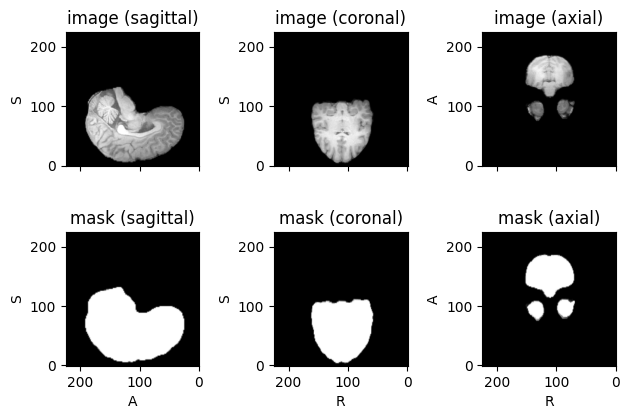

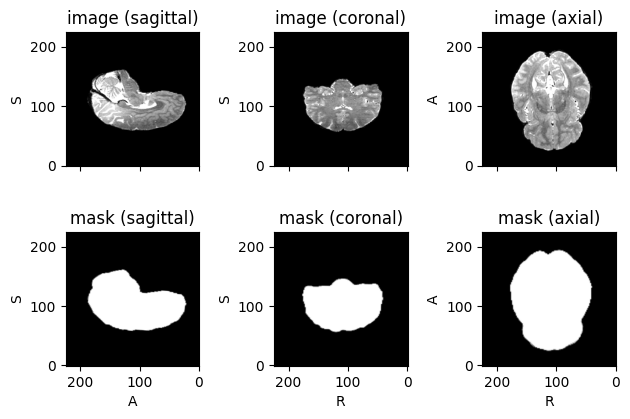

In [19]:
cropped_t1 = tio.CropOrPad((225, 225, 225))(resampled_t1)
cropped_t2 = tio.CropOrPad((225, 225, 225))(resampled_t2)

# Plot the cropped images
cropped_t1.plot()
cropped_t2.plot()

**7. Resizing**

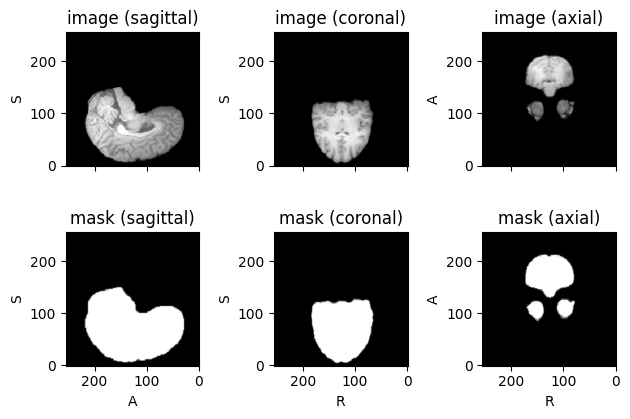

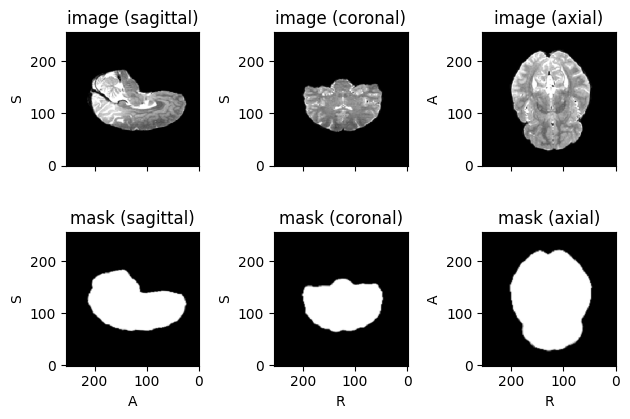

In [20]:
resized_t1 = tio.Resize(target_shape=(256,256,256), image_interpolation='nearest')(cropped_t1)
resized_t2 = tio.Resize(target_shape=(256,256,256), image_interpolation='nearest')(cropped_t2)

# Plot the resized images
resized_t1.plot()
resized_t2.plot()

**8. Data Augmentation**

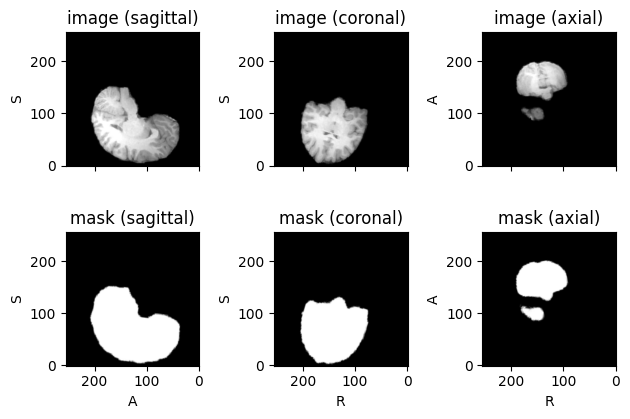

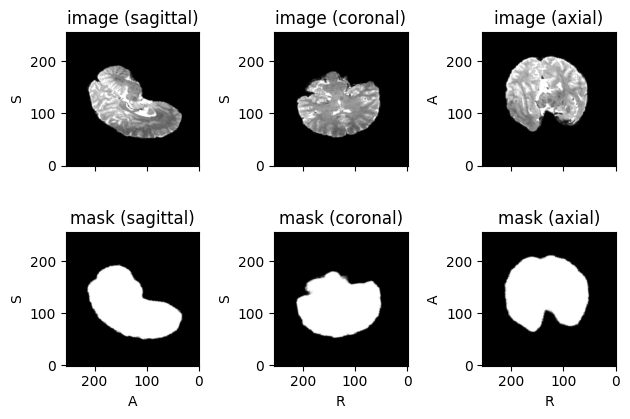

In [21]:
augmented_t1 = tio.RandomAffine(degrees=15, translation=10)(resized_t1)
augmented_t2 = tio.RandomAffine(degrees=15, translation=10)(resized_t2)

# Plot the augmented images
augmented_t1.plot()
augmented_t2.plot()

**Noise Generation**

In [46]:
noise = torch.randn_like(augmented_t1.image.data) * augmented_t1.image.data.std() + augmented_t1.image.data.mean()
noisy_image = augmented_t1.image.data.clone()
noisy_image = augmented_t1.image.data + noise * augmented_t1.mask.data

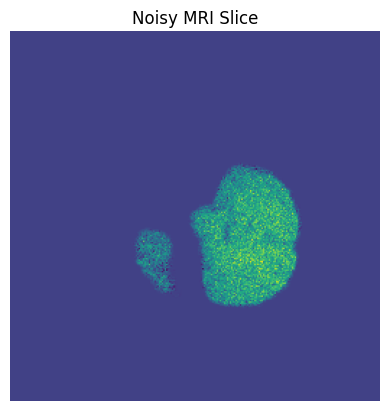

In [40]:
import matplotlib.pyplot as plt

# Convert to NumPy if it's a PyTorch tensor
if isinstance(noisy_image, torch.Tensor):
    noisy_mri = noisy_image.squeeze().cpu().numpy()  # Remove batch/channel dims if needed

# Select a middle slice (for 3D images)
slice_idx = noisy_mri.shape[-1] // 2  # Middle slice along the last dimension
slice_image = noisy_mri[:, :, slice_idx]  # Extract the slice

# Display the slice
plt.imshow(slice_image
        #    , cmap="gray"
           )
plt.axis("off")
plt.title("Noisy MRI Slice")
plt.show()